In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

In [5]:
print("X:")
print(X[:10])

print("\ny:")
print(y[:10])

X:
[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]
 [ 0.11182668 -0.55193153]
 [-0.81646618  0.54399604]
 [ 0.66250998 -0.08435588]
 [ 0.27450961 -0.18990367]
 [-0.11555577  0.53591195]
 [ 1.57236902 -0.33544711]
 [ 0.76398981  0.96235883]]

y:
[1 1 1 1 0 1 1 1 1 0]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

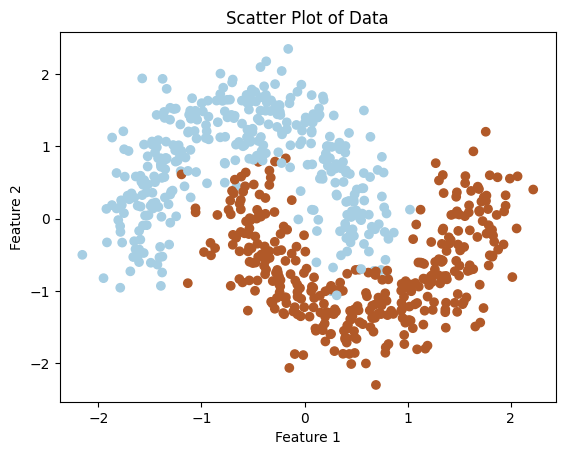

In [7]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Paired)
plt.title('Scatter Plot of Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [9]:
!pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 2.1/350.9 MB 7.8 MB/s eta 0:00:45
   ---------------------------------------- 4.2/350.9 MB 8.7 MB/s eta 0:00:40
    --------------------------------------- 6.3/350.9 MB 8.8 MB/s eta 0:00:40
    --------------------------------------- 7.3/350.9 MB 8.0 MB/s eta 0:00:44
    --------------------------------------- 8.7/350.9 MB 7.5 MB/s eta 0:00:46
   - -------------------------------------- 10.0/350.9 MB 7.3 MB/s eta 0:00:47
   - -------------------------------------- 11.3/350.9 MB 7.2 MB/s eta 0:00:48
   - -------------------------------------- 12.8/350.9 MB 7.3 MB/s eta 0:00:47
   - -------------------------------------- 14.7/350.9 MB 7.4 MB/s eta 0:00:46
   - -------------------------------------- 16.0/350.9 MB 7.5 MB/s eta 0:00:45
   -- ------------------------------------- 17.8/350.9 MB 7.5 MB/s


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model = Sequential([
    Dense(10, input_shape = (2,), activation='relu'),
    Dense(10, activation='relu'),
    Dense(1,activation='sigmoid')
])

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5018 - loss: 0.6715 - val_accuracy: 0.4500 - val_loss: 0.6742
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4964 - loss: 0.6223 - val_accuracy: 0.4429 - val_loss: 0.6250
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4714 - loss: 0.5855 - val_accuracy: 0.4429 - val_loss: 0.5869
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5286 - loss: 0.5567 - val_accuracy: 0.6429 - val_loss: 0.5585
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7232 - loss: 0.5348 - val_accuracy: 0.7714 - val_loss: 0.5360
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7982 - loss: 0.5170 - val_accuracy: 0.8357 - val_loss: 0.5184
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8214 - loss: 0.5025 - val_accuracy: 0.8500 - val_loss: 0.5016
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8375 - loss: 0.4889 - val_accuracy: 0.8500 - 

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss : {loss:.4f}')
print(f'Test Accuract : {accuracy:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9733 - loss: 0.0820 
Test Loss : 0.0820
Test Accuract : 0.9733


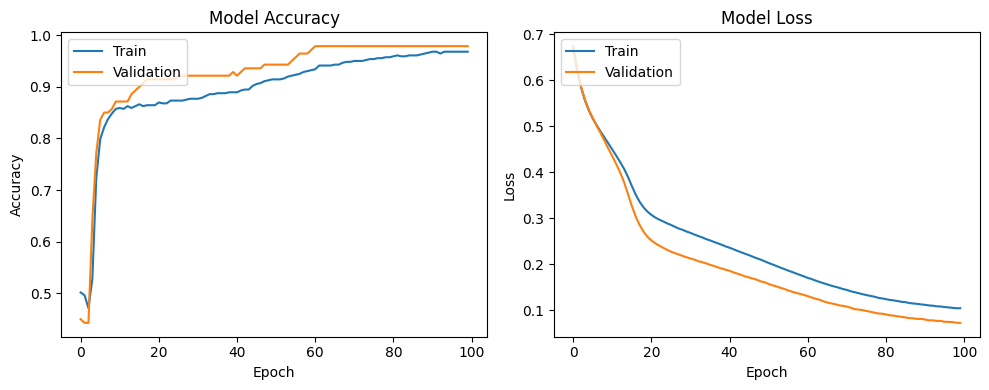

In [24]:
plt.figure(figsize=(10,4))
# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred_classes))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       156
           1       0.98      0.97      0.97       144

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



In [26]:
#Data baru untuk diuji (contoh 2 titik data)
X_new = np.array([[0.5, 0.3], [1.2, -0.8]])
proba = model.predict(scaler.transform(X_new))
kelas = (proba > 0.5).astype(int)
for d, p, k in zip(X_new, proba, kelas):
    print(f"Data: {d}, Prob kelas 1: {p[0]:.4f}, Prediksi: {k[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Data: [0.5 0.3], Prob kelas 1: 0.3575, Prediksi: 0
Data: [ 1.2 -0.8], Prob kelas 1: 0.9981, Prediksi: 1
